In [1]:
from pathlib import Path
import os

REPO_ROOT = Path.home() / "openpi"
os.chdir(REPO_ROOT)

print("Working directory:", Path.cwd())

Working directory: /home/osx/openpi


In [2]:
import dataclasses

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from openpi.models import model as model_lib
from openpi.models.pi0 import make_attn_mask
from openpi.shared import download
from openpi.training import config
from openpi.training import data_loader

In [3]:
cfg = config.get_config("pi05_libero")

cfg = dataclasses.replace(
    cfg,
    batch_size=1,
    num_workers=0,
)

print("Model:", cfg.model.model_type)
print("Action horizon:", cfg.model.action_horizon)
print("Action dimension:", cfg.model.action_dim)
print("Max prompt tokens:", cfg.model.max_token_len)

Model: ModelType.PI05
Action horizon: 10
Action dimension: 32
Max prompt tokens: 200


In [ ]:
loader = data_loader.create_data_loader(
    cfg,
    shuffle=False,
    num_batches=1,
)

obs, actions = next(iter(loader))

print("state:", obs.state.shape)
print("actions:", actions.shape)
print("prompt tokens:", obs.tokenized_prompt.shape)

for name, image in obs.images.items():
    print(
        name,
        image.shape,
        image.dtype,
    )

The dataset you requested (physical-intelligence/libero) is in 2.0 format.
While current version of LeRobot is backward-compatible with it, the version of your dataset still uses global
stats instead of per-episode stats. Update your dataset stats to the new format using this command:
```
python lerobot/common/datasets/v21/convert_dataset_v20_to_v21.py --repo-id=physical-intelligence/libero
```

If you encounter a problem, contact LeRobot maintainers on [Discord](https://discord.com/invite/s3KuuzsPFb)
or open an [issue on GitHub](https://github.com/huggingface/lerobot/issues/new/choose).

The dataset you requested (physical-intelligence/libero) is in 2.0 format.
While current version of LeRobot is backward-compatible with it, the version of your dataset still uses global
stats instead of per-episode stats. Update your dataset stats to the new format using this command:
```
python lerobot/common/datasets/v21/convert_dataset_v20_to_v21.py --repo-id=physical-intelligence/libero
```

If yo

Resolving data files:   0%|          | 0/1693 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/70 [00:00<?, ?it/s]

state: (1, 32)
actions: (1, 10, 32)
prompt tokens: (1, 200)
base_0_rgb (1, 224, 224, 3) float32
left_wrist_0_rgb (1, 224, 224, 3) float32
right_wrist_0_rgb (1, 224, 224, 3) float32


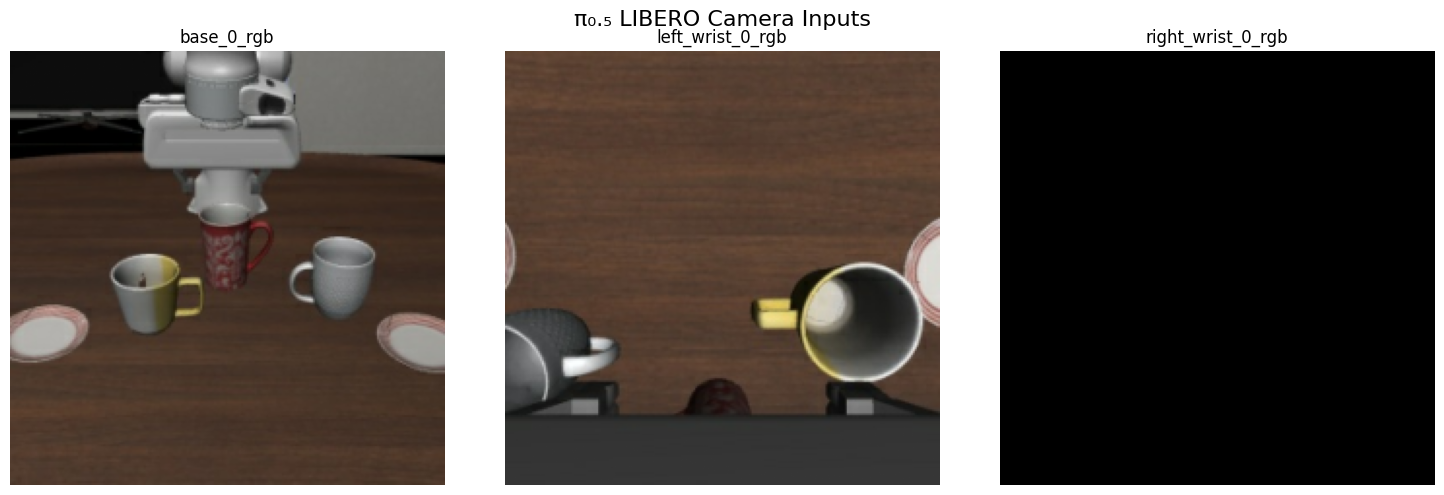

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, image) in zip(axes, obs.images.items()):
    img = np.asarray(image[0])

    # Model images are represented in approximately [-1, 1].
    img_display = np.clip((img + 1.0) / 2.0, 0.0, 1.0)

    ax.imshow(img_display)
    ax.set_title(name)
    ax.axis("off")

plt.suptitle("π₀.₅ LIBERO Camera Inputs", fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
#uv run scripts/compute_norm_stats.py --config-name pi05_libero

state = np.asarray(obs.state[0])
action_chunk = np.asarray(actions[0])

print("========== NORMALIZED STATE ==========")
print("shape:", state.shape)
print("min:", state.min())
print("max:", state.max())
print()
print("first 8 real LIBERO dimensions:")
print(state[:8])

print("\nremaining 24 padded dimensions:")
print(state[8:])

print("\n========== NORMALIZED ACTION CHUNK ==========")
print("shape:", action_chunk.shape)
print("min:", action_chunk.min())
print("max:", action_chunk.max())

print("\nfirst future action, 7 real dimensions:")
print(action_chunk[0, :7])

print("\nfirst future action, 25 padded dimensions:")
print(action_chunk[0, 7:])

========== NORMALIZED STATE ==========
shape: (32,)
min: -0.93428564
max: 0.92140454

first 8 real LIBERO dimensions:
[ 0.29397994 -0.08721764  0.03937005  0.8464661   0.06224303  0.18128327
  0.92140454 -0.93428564]

remaining 24 padded dimensions:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

========== NORMALIZED ACTION CHUNK ==========
shape: (10, 32)
min: -1.0
max: 0.00019950647

first future action, 7 real dimensions:
[-1.2024813e-01 -4.1639108e-02  1.9950647e-04 -6.8830438e-02
 -7.7574261e-02 -2.0193344e-01 -1.0000000e+00]

first future action, 25 padded dimensions:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0.]


In [ ]:
# Cell 7 — Construct one flow-matching training example

#a       = correct robot action
#epsilon = noise we generated
#t       = how noisy we made it
#x_t     = noisy action given to π₀.₅
#u_t     = correct answer π₀.₅ should predict

rng = jax.random.key(0)

preprocess_rng, noise_rng, time_rng = jax.random.split(rng, 3)

# Ground-truth demonstrated actions
a = actions

# Random Gaussian noise
epsilon = jax.random.normal(
    noise_rng,
    actions.shape,
)

# Random flow timestep
t = (
    jax.random.beta(
        time_rng,
        1.5,
        1,
        actions.shape[:-2],
    )
    * 0.999
    + 0.001
)

t_expanded = t[..., None, None]

# Mix the correct action with noise
x_t = t_expanded * epsilon + (1 - t_expanded) * a

# Correct vector field that π0.5 should predict
u_t = epsilon - a

print("flow timestep t:", float(t[0]))

print("\na:", a.shape)
print("epsilon:", epsilon.shape)
print("x_t:", x_t.shape)
print("u_t:", u_t.shape)

print("\nFirst 7 values at action timestep 0:")
print("a       =", np.asarray(a[0, 0, :7]))
print("epsilon =", np.asarray(epsilon[0, 0, :7]))
print("x_t     =", np.asarray(x_t[0, 0, :7]))
print("u_t     =", np.asarray(u_t[0, 0, :7]))

In [7]:
# Cell 8 — Load pretrained π0.5

checkpoint_dir = download.maybe_download(
    "gs://openpi-assets/checkpoints/pi05_base"
)

params = model_lib.restore_params(
    checkpoint_dir / "params",
    dtype=jnp.bfloat16,
)

model = cfg.model.load(params)
model.eval()

print("π0.5 loaded")
print("action horizon:", model.action_horizon)
print("action dim:", model.action_dim)

π0.5 loaded
action horizon: 10
action dim: 32


In [ ]:
# Cell 9 — π0.5 predicts the vector field

#The outputs are:

#prefix_tokens - The actual embedding vectors that will enter the transformer.

#prefix_mask - Which prefix positions contain valid data.

#prefix_ar_mask - How those positions are allowed to attend to one another.

obs_processed = model_lib.preprocess_observation(
    preprocess_rng,
    obs,
    train=False, #randomize/augment data for training
)

prefix_tokens, prefix_mask, prefix_ar_mask = model.embed_prefix(
    obs_processed
)

suffix_tokens, suffix_mask, suffix_ar_mask, adarms_cond = (
    model.embed_suffix(
        obs_processed,
        x_t,
        t,
    )
)

input_mask = jnp.concatenate(
    [prefix_mask, suffix_mask],
    axis=1,
)

ar_mask = jnp.concatenate(
    [prefix_ar_mask, suffix_ar_mask],
    axis=0,
)

attn_mask = make_attn_mask(
    input_mask,
    ar_mask,
)

positions = jnp.cumsum(
    input_mask,
    axis=1,
) - 1

(prefix_out, suffix_out), _ = model.PaliGemma.llm(
    [prefix_tokens, suffix_tokens],
    mask=attn_mask,
    positions=positions,
    adarms_cond=[None, adarms_cond],
)

v_theta = model.action_out_proj(
    suffix_out[:, -model.action_horizon:]
)

print("target u_t:", u_t.shape)
print("prediction v_theta:", v_theta.shape)

print("\nFirst 7 target values:")
print(np.asarray(u_t[0, 0, :7]))

print("\nFirst 7 predicted values:")
print(np.asarray(v_theta[0, 0, :7]))

In [ ]:
# Cell 10 — Compute flow-matching loss manually

error = v_theta - u_t

squared_error = jnp.square(error)

# Average across the 32 action dimensions
loss_per_timestep = jnp.mean(
    squared_error,
    axis=-1,
)

# Average across batch + 10 future timesteps
mean_loss = jnp.mean(loss_per_timestep)

print("error shape:", error.shape)
print("squared error shape:", squared_error.shape)
print("loss per timestep shape:", loss_per_timestep.shape)

print("\nLoss per timestep:")
print(np.asarray(loss_per_timestep))

print("\nMean loss:")
print(float(mean_loss))

In [ ]:
# Cell 11 — Verify our manual calculation

official_loss = model.compute_loss(
    rng,
    obs,
    actions,
    train=False,
)

print("Manual:")
print(np.asarray(loss_per_timestep))

print("\nOpenPI compute_loss():")
print(np.asarray(official_loss))

print(
    "\nMatch:",
    np.allclose(
        np.asarray(loss_per_timestep),
        np.asarray(official_loss),
        atol=1e-5,
    ),
)

In [8]:
# Cell 12 — Create a low-memory π0.5 LoRA training config

from openpi.models import pi0_config
from openpi.training import optimizer as optimizer_lib

lora_model_cfg = pi0_config.Pi0Config(
    pi05=True,
    action_horizon=10,
    discrete_state_input=False,
    paligemma_variant="gemma_2b_lora",
    action_expert_variant="gemma_300m_lora",
)

lora_cfg = dataclasses.replace(
    cfg,

    # Replace normal π0.5 with LoRA-enabled π0.5
    model=lora_model_cfg,

    # Only LoRA parameters should remain trainable
    freeze_filter=lora_model_cfg.get_freeze_filter(),

    # EMA is normally disabled for LoRA fine-tuning
    ema_decay=None,

    # Tiny experiment
    batch_size=1,
    num_workers=4,

    # Don't use the normal 10,000-step warmup for our tiny test
    lr_schedule=optimizer_lib.CosineDecaySchedule(
        warmup_steps=0,
        peak_lr=5e-5,
        decay_steps=1000,
        decay_lr=5e-5,
    ),
)

print("model:", lora_cfg.model.model_type)
print("pi05:", lora_cfg.model.pi05)
print("PaliGemma:", lora_cfg.model.paligemma_variant)
print("Action expert:", lora_cfg.model.action_expert_variant)
print("action horizon:", lora_cfg.model.action_horizon)
print("EMA:", lora_cfg.ema_decay)

model: ModelType.PI05
pi05: True
PaliGemma: gemma_2b_lora
Action expert: gemma_300m_lora
action horizon: 10
EMA: None


In [9]:
# Cell 13 — Free the inference model before constructing the LoRA model
# Garbage collection
import gc

del model
del params

gc.collect()
jax.clear_caches()

print("Old π0.5 inference model released.")

Old π0.5 inference model released.


In [10]:
# Cell 14 — Inspect which π0.5 parameters LoRA will train

import flax.nnx as nnx


model_shape = nnx.eval_shape(
    lora_cfg.model.create,
    jax.random.key(0),
)

all_params = nnx.state(model_shape)

trainable_params = all_params.filter(
    lora_cfg.trainable_filter
)


def count_params(state):
    pure = state.to_pure_dict()

    return sum(
        np.prod(x.shape)
        for x in jax.tree_util.tree_leaves(pure)
    )


total_count = count_params(all_params)
trainable_count = count_params(trainable_params)
frozen_count = total_count - trainable_count

print(f"Total parameters:     {total_count:,}")
print(f"Trainable parameters: {trainable_count:,}")
print(f"Frozen parameters:    {frozen_count:,}")
print()

print(
    "Trainable percentage:",
    f"{100 * trainable_count / total_count:.3f}%"
)

Total parameters:     3,403,421,456
Trainable parameters: 466,957,072
Frozen parameters:    2,936,464,384

Trainable percentage: 13.720%


In [11]:
# Cell 15 — Initialize π0.5 LoRA training

import functools

from scripts import train as train_lib
from openpi.training import sharding


mesh = sharding.make_mesh(
    lora_cfg.fsdp_devices
)

init_rng = jax.random.key(42)

train_state, _ = train_lib.init_train_state(
    lora_cfg,
    init_rng,
    mesh,
    resume=False,
)

jax.block_until_ready(train_state)

print("Training state initialized.")
print("Starting step:", int(train_state.step))

2026-09-13 23:14:21.557495: W external/xla/xla/hlo/transforms/simplifiers/hlo_rematerialization.cc:3021] Can't reduce memory use below 6.95GiB (7458157411 bytes) by rematerialization; only reduced to 10.69GiB (11478512400 bytes), down from 10.69GiB (11478512896 bytes) originally


Training state initialized.
Starting step: 0


In [ ]:
# Cell 16 — Tiny overfit with live loss plot

import functools

from IPython.display import clear_output
from scripts import train as train_lib


# Compile the actual OpenPI training step.
# Keeping this here prevents a hidden dependency on an older notebook cell.
p_train_step = jax.jit(
    functools.partial(
        train_lib.train_step,
        lora_cfg,
    ),
    donate_argnums=(1,),
)

# Base RNG. train_step folds the current training step into this key,
# so each optimization step still gets different random noise / flow time.
train_rng = jax.random.key(123)

num_steps = 100

steps = []
losses = []

for i in range(num_steps):

    train_state, info = p_train_step(
        train_rng,
        train_state,
        (obs, actions),
    )

    # Wait for the GPU computation to finish before reading/logging results.
    jax.block_until_ready(info)

    loss = float(info["loss"])

    steps.append(int(train_state.step))
    losses.append(loss)

    # Redraw the live plot every 5 optimization steps.
    if i % 5 == 0 or i == num_steps - 1:

        clear_output(wait=True)

        plt.figure(figsize=(9, 5))

        plt.plot(
            steps,
            losses,
            label="Training loss",
        )

        plt.xlabel("Training step")
        plt.ylabel("Flow-matching loss")
        plt.title("π₀.₅ Tiny-Overfit Training Loss")
        plt.grid(True)
        plt.legend()

        plt.show()

        print("step:", steps[-1])
        print("loss:", losses[-1])
        print("gradient norm:", float(info["grad_norm"]))

In [ ]:
# Cell 17 — Compare before vs after training using identical noise and timestep

import flax.nnx as nnx

trained_model = nnx.merge(
    train_state.model_def,
    train_state.params,
)

trained_model.eval()

eval_rng = jax.random.key(0)

trained_loss = trained_model.compute_loss(
    eval_rng,
    obs,
    actions,
    train=False,
)

initial_mean_loss = float(jnp.mean(official_loss))
trained_mean_loss = float(jnp.mean(trained_loss))

print("Initial fixed loss:", initial_mean_loss)
print("Trained fixed loss:", trained_mean_loss)

print(
    "Reduction:",
    f"{100 * (1 - trained_mean_loss / initial_mean_loss):.2f}%"
)

In [ ]:
# Cell 18 — Build a tiny 32-example LIBERO training set
import functools
from scripts import train as train_lib

tiny_loader = data_loader.create_data_loader(
    lora_cfg,
    shuffle=True,
    num_batches=32,
)

tiny_batches = list(tiny_loader)

print("Tiny training examples:", len(tiny_batches))

for i, (batch_obs, batch_actions) in enumerate(tiny_batches[:3]):
    print(
        f"sample {i}:",
        "state", batch_obs.state.shape,
        "actions", batch_actions.shape,
    )

p_train_step = jax.jit(
    functools.partial(
        train_lib.train_step,
        lora_cfg,
    ),
    donate_argnums=(1,),
)

train_rng = jax.random.key(123)

print("Training step ready.")
print("Current model step:", int(train_state.step))

In [ ]:
# Cell 19 — Tiny-subset fine-tuning

from IPython.display import clear_output

num_epochs = 5

train_steps = []
train_losses = []

for epoch in range(num_epochs):

    for batch in tiny_batches:

        train_state, info = p_train_step(
            train_rng,
            train_state,
            batch,
        )

        jax.block_until_ready(info)

        train_steps.append(int(train_state.step))
        train_losses.append(float(info["loss"]))

    clear_output(wait=True)

    plt.figure(figsize=(9, 5))

    plt.plot(
        train_steps,
        train_losses,
        alpha=0.35,
        label="Raw training loss",
    )

    # Smoothed loss
    if len(train_losses) >= 20:
        window = 20

        smooth = np.convolve(
            train_losses,
            np.ones(window) / window,
            mode="valid",
        )

        plt.plot(
            train_steps[window - 1:],
            smooth,
            linewidth=2,
            label="20-step moving average",
        )

    plt.xlabel("Training step")
    plt.ylabel("Flow-matching loss")
    plt.title("π₀.₅ Fine-Tuning on 32 LIBERO Examples")
    plt.legend()
    plt.grid(True)
    plt.show()

    print(f"Epoch {epoch + 1}/{num_epochs}")
    print("Current loss:", train_losses[-1])

In [ ]:
# Cell 20 — Summarize tiny-subset training

window = 20

start_loss = np.mean(train_losses[:window])
end_loss = np.mean(train_losses[-window:])

print("Average loss, first 20 steps:", start_loss)
print("Average loss, last 20 steps:", end_loss)

print(
    "Training-loss reduction:",
    f"{100 * (1 - end_loss / start_loss):.2f}%"
)

In [ ]:
# Cell 21 — Held-out evaluation set

eval_loader = data_loader.create_data_loader(
    lora_cfg,
    shuffle=False,
    num_batches=16,
)

eval_batches = list(eval_loader)

trained_model = nnx.merge(
    train_state.model_def,
    train_state.params,
)

trained_model.eval()

eval_losses = []

for i, (eval_obs, eval_actions) in enumerate(eval_batches):
    eval_rng = jax.random.key(i)

    loss = trained_model.compute_loss(
        eval_rng,
        eval_obs,
        eval_actions,
        train=False,
    )

    eval_losses.append(
        float(jnp.mean(loss))
    )

print("Held-out examples:", len(eval_losses))
print("Mean held-out loss:", np.mean(eval_losses))

In [ ]:
trained_eval_mean = float(np.mean(eval_losses))

print("Fine-tuned held-out loss:", trained_eval_mean)

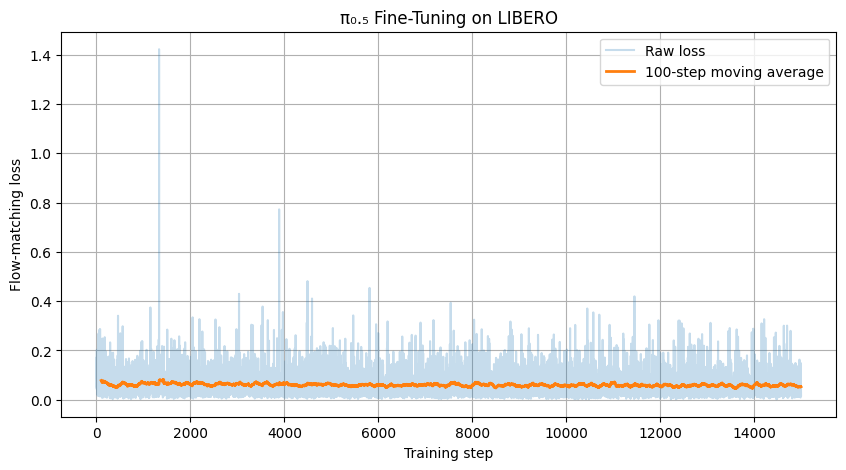

step: 15000 / 15000
current loss: 0.018231
last-100 mean loss: 0.052957
gradient norm: 0.24328528344631195


Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/home/osx/.cache/uv/archive-v0/8i5tnZ0b8gJ1TZhk/lib/python3.11/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/osx/.cache/uv/archive-v0/8i5tnZ0b8gJ1TZhk/lib/python3.11/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/home/osx/.cache/uv/archive-v0/8i5tnZ0b8gJ1TZhk/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io_loop.start()
  File "/home/osx/.cache/uv/archive-v0/8i5tnZ0b8gJ1TZhk/lib/python3.11/site-packages/tornado/platform/asyncio.py", line 211, in start
    self.asyncio_loop.run_forever()
  File "/home/osx/.local/share/uv/python/cpython-3.11.16-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py", line 608, in run_forever
    self._run_once()
  File "/home/osx/.local/share/uv/python/cpython-3.

In [12]:
# Cell 22 — Full LIBERO fine-tuning run

import functools

from IPython.display import clear_output
from scripts import train as train_lib


# Number of optimization updates for the first large run
num_steps = 15000


# Stream from the entire LIBERO dataset.
# Do NOT convert this loader to list(...).
full_loader = data_loader.create_data_loader(
    lora_cfg,
    shuffle=True,
    num_batches=num_steps,
)


# Compile OpenPI's actual training step
p_train_step = jax.jit(
    functools.partial(
        train_lib.train_step,
        lora_cfg,
    ),
    donate_argnums=(1,),
)

train_rng = jax.random.key(123)


# Training history
full_steps = []
full_losses = []


for i, batch in enumerate(full_loader):

    train_state, info = p_train_step(
        train_rng,
        train_state,
        batch,
    )

    jax.block_until_ready(info)

    step = int(train_state.step)
    loss = float(info["loss"])

    full_steps.append(step)
    full_losses.append(loss)


    # Updating the graph every single step wastes time.
    # Every 25 steps is enough to watch training live.
    if i % 25 == 0 or i == num_steps - 1:

        clear_output(wait=True)

        plt.figure(figsize=(10, 5))

        # Raw stochastic training loss
        plt.plot(
            full_steps,
            full_losses,
            alpha=0.25,
            label="Raw loss",
        )

        # Smoothed trend
        window = 100

        if len(full_losses) >= window:

            smooth = np.convolve(
                full_losses,
                np.ones(window) / window,
                mode="valid",
            )

            plt.plot(
                full_steps[window - 1:],
                smooth,
                linewidth=2,
                label="100-step moving average",
            )

        plt.xlabel("Training step")
        plt.ylabel("Flow-matching loss")
        plt.title("π₀.₅ Fine-Tuning on LIBERO")
        plt.legend()
        plt.grid(True)

        plt.show()

        recent = min(100, len(full_losses))

        print(f"step: {step} / {num_steps}")
        print(f"current loss: {loss:.6f}")
        print(
            f"last-{recent} mean loss:",
            f"{np.mean(full_losses[-recent:]):.6f}",
        )
        print(
            "gradient norm:",
            float(info["grad_norm"]),
        )

In [ ]:
# Cell 22 — Train on 100 LIBERO examples for 10 epochs

import functools
import random

from IPython.display import clear_output
from scripts import train as train_lib


# --------------------------------------------------
# Experiment size
# --------------------------------------------------

num_examples = 100
num_epochs = 10


# --------------------------------------------------
# Select the 100-example training subset ONCE
# --------------------------------------------------

subset_loader = data_loader.create_data_loader(
    lora_cfg,
    shuffle=True,
    num_batches=num_examples,
)

training_batches = list(subset_loader)

print("Training examples:", len(training_batches))


# --------------------------------------------------
# Compile OpenPI's training step
# --------------------------------------------------

p_train_step = jax.jit(
    functools.partial(
        train_lib.train_step,
        lora_cfg,
    ),
    donate_argnums=(1,),
)

train_rng = jax.random.key(123)


# --------------------------------------------------
# Training history
# --------------------------------------------------

train_steps = []
train_losses = []
epoch_losses = []


# --------------------------------------------------
# Train
# --------------------------------------------------

for epoch in range(num_epochs):

    # Same 100 examples, different order each epoch
    random.shuffle(training_batches)

    current_epoch_losses = []

    for batch in training_batches:

        train_state, info = p_train_step(
            train_rng,
            train_state,
            batch,
        )

        jax.block_until_ready(info)

        step = int(train_state.step)
        loss = float(info["loss"])

        train_steps.append(step)
        train_losses.append(loss)
        current_epoch_losses.append(loss)


    # Mean loss for this entire epoch
    epoch_mean = float(np.mean(current_epoch_losses))
    epoch_losses.append(epoch_mean)


    # --------------------------------------------------
    # Update graph once per epoch
    # --------------------------------------------------

    clear_output(wait=True)

    plt.figure(figsize=(10, 5))

    # Raw stochastic loss
    plt.plot(
        train_steps,
        train_losses,
        alpha=0.25,
        label="Raw loss",
    )

    # Moving average
    window = 50

    if len(train_losses) >= window:
        smooth = np.convolve(
            train_losses,
            np.ones(window) / window,
            mode="valid",
        )

        plt.plot(
            train_steps[window - 1:],
            smooth,
            linewidth=2,
            label="50-step moving average",
        )

    plt.xlabel("Training step")
    plt.ylabel("Flow-matching loss")
    plt.title("π₀.₅ LIBERO Fine-Tuning — 100 Examples × 10 Epochs")
    plt.legend()
    plt.grid(True)

    plt.show()

    print(f"Epoch: {epoch + 1} / {num_epochs}")
    print(f"Training step: {int(train_state.step)}")
    print(f"Epoch mean loss: {epoch_mean:.6f}")
    print(f"Current loss: {train_losses[-1]:.6f}")